# YOLOv8 Person Segmentation — Commented Notebook

End-to-end pipeline (macOS + Apple Silicon MPS):
1) Download COCO annotations only
2) Download a person-only image subset (2000 train / 200 val)
3) Convert COCO polygons → YOLO-seg labels
4) Fine-tune YOLOv8n-seg
5) Preview predictions + background blur
6) Export ONNX


## 0) Configuration

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson")
DATA_DIR = Path(r"/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco_person_subset")          # images/ + labels/ live here
COCO_ROOT = Path(r"/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco")        # annotations live here
YAML_PATH = Path(r"/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco_person_subset.yaml")

N_TRAIN = 2000
N_VAL = 200
SEED = 0

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("COCO_ROOT    :", COCO_ROOT)
print("YAML_PATH    :", YAML_PATH)


PROJECT_ROOT: /Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson
DATA_DIR     : /Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco_person_subset
COCO_ROOT    : /Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco
YAML_PATH    : /Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco_person_subset.yaml


## 1) Install deps + download COCO annotations

In [ ]:
!pip -q install tqdm pycocotools ultralytics opencv-python matplotlib

from pathlib import Path

COCO_ROOT.mkdir(parents=True, exist_ok=True)

%cd /Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco

!curl -L -o annotations_trainval2017.zip http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q -o annotations_trainval2017.zip

!ls -la annotations | head -n 20


## 2) Download person-only subset images (train/val)

In [ ]:
import json, random, urllib.request
from pathlib import Path
from tqdm import tqdm

PERSON_CAT_ID = 1  # COCO category_id for 'person'

COCO_ANN_TRAIN = COCO_ROOT / "annotations" / "instances_train2017.json"
COCO_ANN_VAL   = COCO_ROOT / "annotations" / "instances_val2017.json"

(TRAIN_IMG_DIR := DATA_DIR / "images" / "train").mkdir(parents=True, exist_ok=True)
(VAL_IMG_DIR   := DATA_DIR / "images" / "val").mkdir(parents=True, exist_ok=True)

def pick_person_images(ann_json_path: Path, n: int, seed: int):
    data = json.loads(ann_json_path.read_text())
    person_img_ids = {a["image_id"] for a in data["annotations"]
                      if a.get("category_id") == PERSON_CAT_ID and a.get("iscrowd", 0) == 0}
    imgs = [im for im in data["images"] if im["id"] in person_img_ids]
    random.seed(seed)
    random.shuffle(imgs)
    return imgs[:n], data

def download_images(imgs, base_url: str, out_dir: Path):
    for im in tqdm(imgs, desc=f"Downloading -> {out_dir.name}"):
        url = base_url + im["file_name"]
        dst = out_dir / im["file_name"]
        if not dst.exists():
            urllib.request.urlretrieve(url, dst)

train_imgs, _ = pick_person_images(COCO_ANN_TRAIN, N_TRAIN, seed=SEED)
val_imgs, _   = pick_person_images(COCO_ANN_VAL,   N_VAL,   seed=SEED)

download_images(train_imgs, "http://images.cocodataset.org/train2017/", TRAIN_IMG_DIR)
download_images(val_imgs,   "http://images.cocodataset.org/val2017/",   VAL_IMG_DIR)

print("Train images:", len(list(TRAIN_IMG_DIR.glob('*.jpg'))))
print("Val images  :", len(list(VAL_IMG_DIR.glob('*.jpg'))))


## 3) Convert COCO polygons → YOLO-seg labels (person-only)

In [ ]:
import json
from pathlib import Path
from tqdm import tqdm

(TRAIN_LBL_DIR := DATA_DIR / "labels" / "train").mkdir(parents=True, exist_ok=True)
(VAL_LBL_DIR   := DATA_DIR / "labels" / "val").mkdir(parents=True, exist_ok=True)

def build_maps(data):
    img_by_id = {im["id"]: im for im in data["images"]}
    anns_by_img = {}
    for a in data["annotations"]:
        if a.get("iscrowd", 0) == 1:
            continue
        if a.get("category_id") != PERSON_CAT_ID:
            continue
        seg = a.get("segmentation")
        if not seg or not isinstance(seg, list):
            continue
        anns_by_img.setdefault(a["image_id"], []).append(a)
    return img_by_id, anns_by_img

def write_yolo_seg_labels(selected_files: set[str], data, out_lbl_dir: Path):
    img_by_id, anns_by_img = build_maps(data)
    written = 0

    # Only write labels for images we actually downloaded (match by filename)
    for im in tqdm(data["images"], desc=f"Writing labels -> {out_lbl_dir.name}"):
        if im["file_name"] not in selected_files:
            continue

        w, h = im["width"], im["height"]
        anns = anns_by_img.get(im["id"], [])
        if not anns:
            continue

        lines = []
        for a in anns:
            for poly in a["segmentation"]:
                if len(poly) < 6:
                    continue
                coords = []
                for i in range(0, len(poly), 2):
                    coords.append(poly[i] / w)
                    coords.append(poly[i + 1] / h)
                lines.append("0 " + " ".join(f"{v:.6f}" for v in coords))

        if lines:
            (out_lbl_dir / f"{Path(im['file_name']).stem}.txt").write_text("\n".join(lines))
            written += 1

    print(f"Wrote {written} label files in {out_lbl_dir}")

train_data = json.loads(COCO_ANN_TRAIN.read_text())
val_data   = json.loads(COCO_ANN_VAL.read_text())

train_files = {p.name for p in (DATA_DIR / "images/train").glob("*.jpg")}
val_files   = {p.name for p in (DATA_DIR / "images/val").glob("*.jpg")}

write_yolo_seg_labels(train_files, train_data, TRAIN_LBL_DIR)
write_yolo_seg_labels(val_files,   val_data,   VAL_LBL_DIR)

print("Train labels:", len(list(TRAIN_LBL_DIR.glob("*.txt"))))
print("Val labels  :", len(list(VAL_LBL_DIR.glob("*.txt"))))


## 4) Write YOLO dataset YAML

In [ ]:
yaml_text = f"""
path: {DATA_DIR.as_posix()}
train: images/train
val: images/val

names:
  0: person
"""

YAML_PATH.write_text(yaml_text.strip())
print("Wrote:", YAML_PATH)
print(YAML_PATH.read_text())


## 5) Fine-tune YOLOv8n-seg on MPS (fast settings)

In [ ]:
import torch
print("MPS available:", torch.backends.mps.is_available())

# Remove stale caches if you changed dataset files
!find "/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco_person_subset" -name "*.cache" -delete

# Train quickly for a deadline: fine-tune pretrained weights, no per-epoch validation
!yolo task=segment mode=train \
  model=yolov8n-seg.pt \
  data="/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/content/coco_person_subset.yaml" \
  imgsz=416 epochs=30 batch=8 device=mps cache=False \
  conf=0.5 max_det=100 \
  val=False \
  name=person_fast_ft


## 6) Preview predictions on 10 images

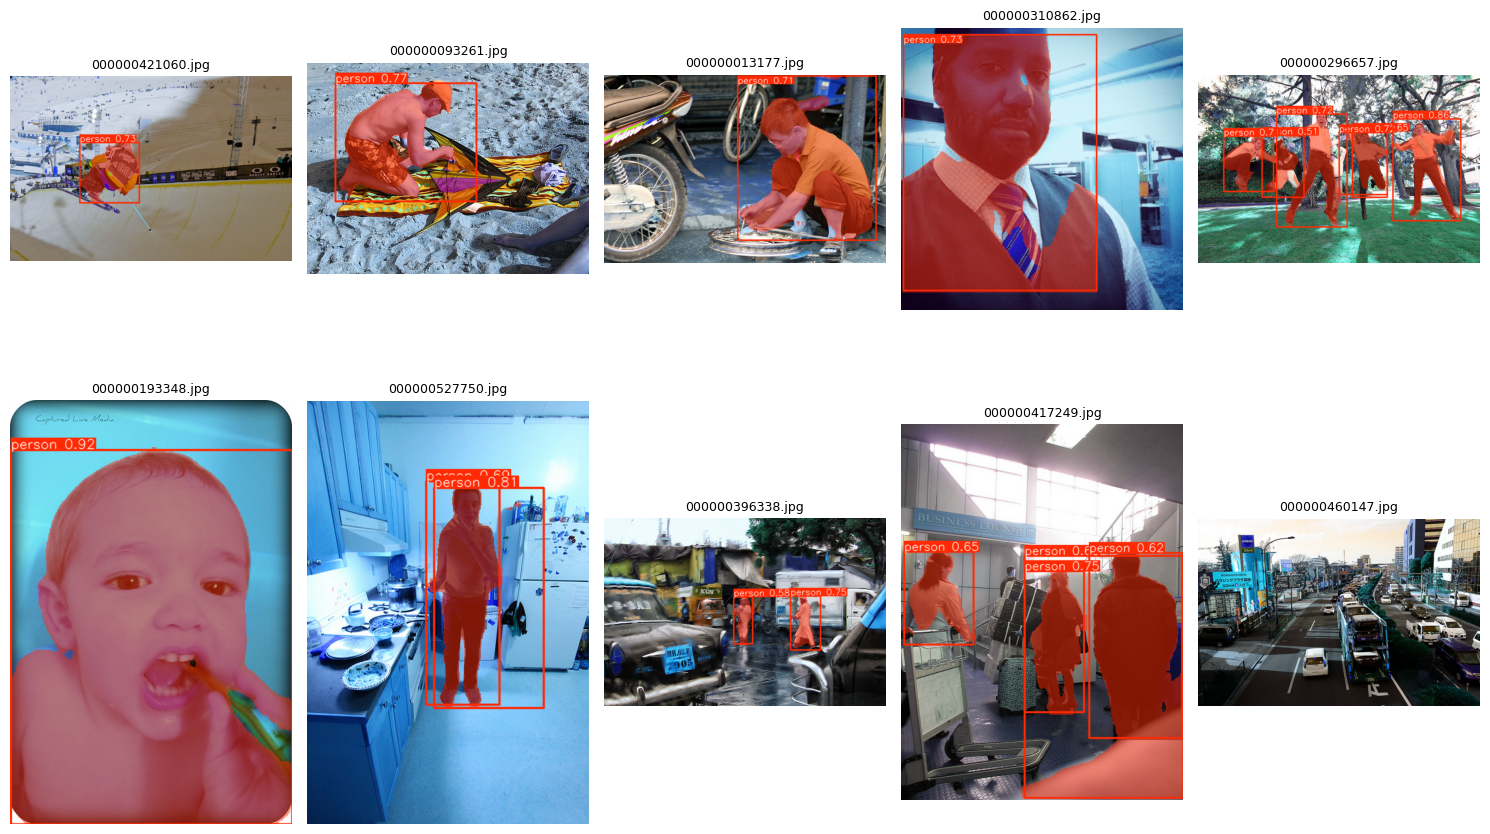

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path
import random

MODEL_PATH = Path(r"/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/runs/segment/person_fast_ft") / "weights" / "last.pt"
IMAGE_DIR = DATA_DIR / "images" / "val"

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
images = list(IMAGE_DIR.glob("*.jpg"))
random.seed(0)
sample = random.sample(images, k=min(10, len(images)))

model = YOLO(str(MODEL_PATH))
results = model.predict([str(p) for p in sample], imgsz=416, conf=0.5, device="mps", verbose=False)

plt.figure(figsize=(15, 10))
for i, r in enumerate(results):
    plt.subplot(2, 5, i + 1)
    plt.imshow(r.plot())
    plt.axis("off")
    plt.title(sample[i].name, fontsize=9)
plt.tight_layout()
plt.show()


## 7) Export the trained model to ONNX

In [ ]:
from ultralytics import YOLO
from pathlib import Path

weights_dir = Path(r"/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/runs/segment/person_fast_ft") / "weights"
best = weights_dir / "best.pt"
last = weights_dir / "last.pt"
model_path = best if best.exists() else last

print("Exporting:", model_path)
model = YOLO(str(model_path))
onnx_path = model.export(format="onnx", imgsz=416, opset=12, simplify=True)
print("Exported ONNX:", onnx_path)


## 8) Background blur preview on 10 images

No mask for: 000000421060.jpg
No mask for: 000000093261.jpg
No mask for: 000000013177.jpg
No mask for: 000000310862.jpg
No mask for: 000000296657.jpg


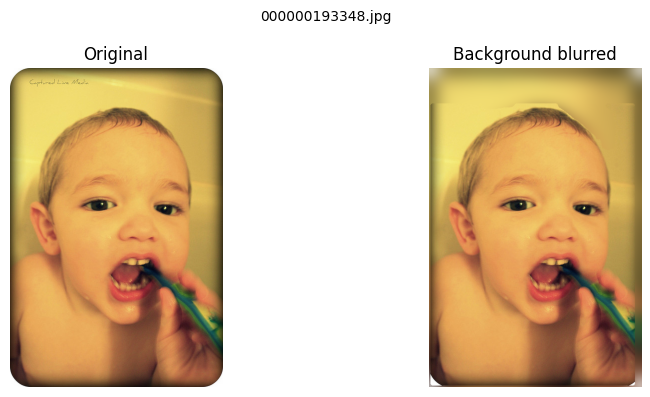

No mask for: 000000527750.jpg


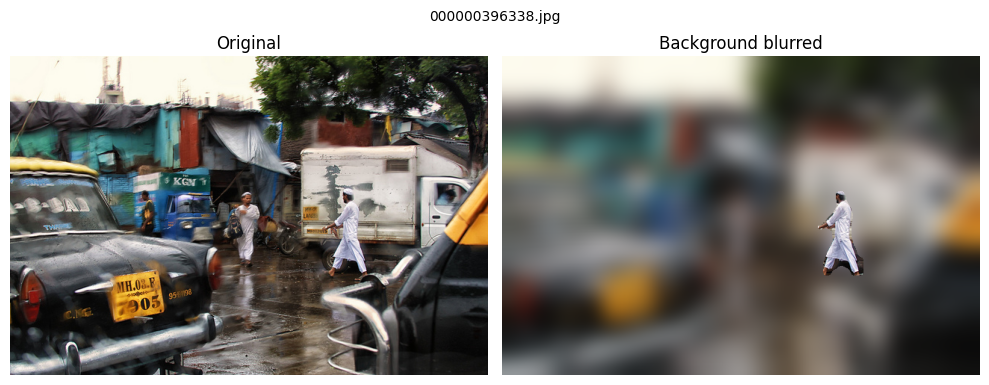

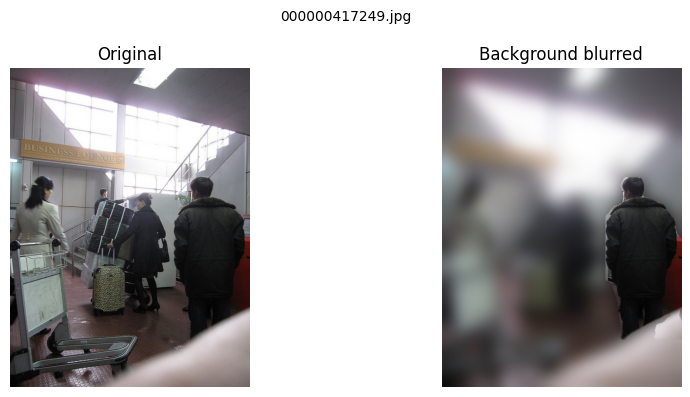

No mask for: 000000460147.jpg


In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random

weights_dir = Path(r"/Users/naokiferrandez/Desktop/5A/Embedded_AI/Projet_Jetson/runs/segment/person_fast_ft") / "weights"
best = weights_dir / "best.pt"
last = weights_dir / "last.pt"
MODEL_PATH = best if best.exists() else last

IMAGE_DIR = DATA_DIR / "images" / "val"
images = list(IMAGE_DIR.glob("*.jpg"))
random.seed(0)
sample = random.sample(images, k=min(10, len(images)))

model = YOLO(str(MODEL_PATH))
BLUR_SIGMA = 15

for p in sample:
    bgr = cv2.imread(str(p))
    h, w = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    res = model.predict(rgb, imgsz=416, conf=0.5, classes=[0], device="mps", verbose=False)[0]
    if res.masks is None:
        print("No mask for:", p.name)
        continue

    mask = np.zeros((h, w), dtype=np.uint8)
    for m in res.masks.data:
        m = (m.detach().cpu().numpy() > 0.5).astype(np.uint8)
        if m.shape != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        mask = np.maximum(mask, m)

    mask = cv2.medianBlur(mask, 7)
    blurred = cv2.GaussianBlur(rgb, (0, 0), sigmaX=BLUR_SIGMA)
    out = np.where(mask[..., None] == 1, rgb, blurred)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(rgb); plt.title("Original"); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(out); plt.title("Background blurred"); plt.axis("off")
    plt.suptitle(p.name, fontsize=10)
    plt.tight_layout()
    plt.show()
